In [ ]:
img = d.screenshot(format='opencv')
result = easyocr_reader.readtext(img)
for i in result:
    print(i)
    print("----")

In [ ]:
import cv2
img = d.screenshot(format='opencv')
# print(img[723,343])
# print(img[709,47])
print(img[190,123])
# 使用該顏色畫一個圖片( 15 , 34 ,180)
print()
# 花園


In [ ]:
battel_names=["暗黑試煉",]
img = d.screenshot(format='opencv')
result = easyocr_reader.readtext(img)
find = False
for i in result:
    if battel_names[0] in i[1]:
        [x1,x2,x3,x4]=i[0]
        find = True
        break
# 找到中心點
if not find:
    print("沒有找到")

center = [int((x1[0]+x3[0])/2)+279,int((x1[1]+x3[1])/2)+70]
result = easyocr_reader.readtext(img[center[1]-40:center[1]+40,center[0]-40:center[0]+30], detail = 0)
print(result)
if '入場' in result:
    d.click(center[0],center[1])
import cv2
import numpy as np
# 劃出中心點
cv2.imshow("img", img[center[1]-40:center[1]+40,center[0]-40:center[0]+30])
cv2.waitKey(0)

In [ ]:
import uiautomator2 as u2
import easyocr
import time
d = u2.connect('emulator-5554')
easyocr_reader = easyocr.Reader(['ch_tra', 'en'])

# 檢測當前應用
def check_in_game():
    if d.app_current().get("package") == "com.mxdzz.tw.and":
        return True
    else:
        return False
def stage_by_str(ocr_str):
    if "公告" in ocr_str:
        return "公告"
    if "方案" in ocr_str:
        return "主頁面"
    if "放置獎勵" in ocr_str or "離線獎勵" in ocr_str:
        return "放置獎勵"
    if '家族商店' in ocr_str or '家族亂鬥' in ocr_str or '鬱鬱胖頭魚' in ocr_str:
        return "家族"
    if "征戰熔岩巨獸" in ocr_str and "掃蕩" in ocr_str:
        return "征戰熔岩巨獸"
    return "未知"
# 尋找該範圍內是否有顏色
def find_color(x1, y1, x2, y2, color):
    img = d.screenshot(format='opencv')
    for i in range(x1, x2):
        for j in range(y1, y2):
            if list(img[i,j]) == color:
                return True
    return False
def reward():
    d.click(162,725)
    time.sleep(5)
    img = d.screenshot(format='opencv')
    result = easyocr_reader.readtext(img, detail = 0)
    if "領取" in result or "放置獎勵" in result:
        if list(img[328,135] )!=[206, 237 ,247]:
            click_white()
            time.sleep(1)
        d.click(389,725)
        time.sleep(5)
        click_white()
        time.sleep(1)
    click_white()
def click_white():
    d.click(509,56)
    time.sleep(1)




def click_str(str1:str):
    img = d.screenshot(format='opencv')
    result = easyocr_reader.readtext(img)
    for i in result:
        if str1 in str(i[1]):
            [x1,x2,x3,x4]=i[0]
            center = [int((x1[0]+x3[0])/2),int((x1[1]+x3[1])/2)]
            d.click(center[0],center[1])
            return True
    return False
# 副本的英文名稱
def battle_instance(battel_names:str,check=False):
    img = d.screenshot(format='opencv')
    result = easyocr_reader.readtext(img)
    find = False
    for i in result:
        if battel_names in i[1]:
            [x1,x2,x3,x4]=i[0]
            find = True
            break
    # 找到中心點
    if not find:
        print("沒有找到")
        return
    center = [int((x1[0]+x3[0])/2)+279,int((x1[1]+x3[1])/2)+70]
    if check ==True:
        result = easyocr_reader.readtext(img[center[1]-40:center[1]+40,center[0]-40:center[0]+30], detail = 0)
        print(result)
        if '入場' not  in result:
            return


    d.click(center[0],center[1])
    time.sleep(1)
    get_time = time.time()
    if battel_names == "守衛":
        while(time.time()-get_time<5):
            d.click(221,772)
        click_white()
        time.sleep(1)
        d.click(267,903)
        time.sleep(3)
        click_str("確定")
        return
    elif battel_names == "暗黑試煉":
        for i in range(5):
            click_str("快速通關")
            time.sleep(3)
            click_str("確認")
            click_white()
            click_str("重置")
            time.sleep(3)
            click_str("確定")
            time.sleep(3)
        d.click(272,878)
        return
    elif battel_names == "探秘焚焰神殿":
        while(time.time()-get_time<5):
            d.click(235,739)
        time.sleep(1)
        click_white()
    else:
        while(time.time()-get_time<5):
            d.click(225,702)
        time.sleep(1)
        click_white()
def all_battle_instance(check):
    battel_names=["突襲神燈小偷","挑戰冰巢龍穴","守衛","顛倒時序塔","探秘焚焰神殿","暗黑試煉"]
    d.swipe(0.5, 0.2, 0.5, 0.8)
    time.sleep(3)
    for i in battel_names:
        battle_instance(i,check)
        time.sleep(5)
        d.swipe(0.5, 0.8, 0.5, 0.65,1)
        time.sleep(5)
    d.click(227,915)

battel_names=["突襲神燈小偷","挑戰冰巢龍穴","守衛","顛倒時序塔","探秘焚焰神殿","暗黑試煉"]
#
# skill_and_partner()
# battle_instance(battel_names[2])
# all_battle_instance()
# [[86, 438], [222, 438], [222, 470], [86, 470]]

In [64]:
d.click(480,929)

In [ ]:
import point
import uiautomator2 as u2
import time
import numpy as np
import cv2
d = u2.connect('emulator-5554')
def find_and_click(d, findImgPath, threshold=0.8):
    img = d.screenshot(format='opencv')
    findImg = cv2.imread(findImgPath)
    res = cv2.matchTemplate(img, findImg, cv2.TM_CCOEFF_NORMED)
    loc = np.where(res >= threshold)
    if len(loc[0]) > 0:
        center = [int(loc[1][0] + findImg.shape[1] / 2), int(loc[0][0] + findImg.shape[0] / 2)]
        d.click(center[0], center[1])
        time.sleep(5)
        return True
    else:
        return False
def go_to_family():
    d.click(407,894)
    time.sleep(5)
    d.click(96,600)
    time.sleep(5)
    target_color = [172, 112, 69]
    pixel_value = d.screenshot(format='opencv')[781, 228]
    target_sum = sum(target_color)
    pixel_sum = sum(pixel_value)

    if  abs(pixel_sum - target_sum) <= 5 and find_and_click(d, r'sweep.png'):
        time.sleep(3)
        print("找到掃蕩")
        d.click(291,552)
        print("點擊掃蕩")
        time.sleep(3)
        d.click(271, 782)
        time.sleep(3)

        d.click(271, 782)
        time.sleep(3)
    d.click(366,561)
    time.sleep(5)
    while(True):
        # 使用函數
        if find_and_click(d, r'family_get.jpg'):
            d.click(271, 782)
            print("找到高級寶箱")
        else:
            print("沒有高級寶箱")
            break
    if find_and_click(d, r'family_get_all.jpg'):
        d.click(271, 782)
        print("找到寶箱")
    else:
        print("沒有寶箱")
    for i in range(2):
        d.click(486, 21)
        time.sleep(3)
    d.click(407,894)
boss_time =0
reward_time = 0
err = 0
other_time = 0
one_day_action = 0
def unlock():
    d.swipe(0.05, 0.7, 0.9, 0.7,0.05)
seed_timme =0
check =True
# 檢測當前應用
def check_in_game():
    if d.app_current().get("package") == "com.mxdzz.tw.and":
        return True
    else:
        return False
def farm():
    d.click(321,920)
    time.sleep(5)
    d.click(208,584)
    time.sleep(5)
    img = d.screenshot(format='opencv')[780:864,:]
    geting = cv2.imread("getting.jpg")
    res = cv2.matchTemplate(img, geting, cv2.TM_CCOEFF_NORMED)
    loc = np.where(res >= 0.8)
    if len(loc[0]) > 0:
        d.click(81, 821)
        time.sleep(7)
        d.click(81, 821)
        time.sleep(1)
    img = d.screenshot(format='opencv')[780:864,:]
    geting = cv2.imread("plants.jpg")
    res = cv2.matchTemplate(img, geting, cv2.TM_CCOEFF_NORMED)
    loc = np.where(res >= 0.8)
    if len(loc[0]) > 0:
        d.click(81, 821)
        time.sleep(2)
        img = d.screenshot(format='opencv')
        target_sum = sum([173 ,112 , 68])
        pixel_sum = sum(img[437,199])
        if (abs(pixel_sum - target_sum) <= 5):
            d.click(199,437)
            time.sleep(2)
            d.click(126,588)
            time.sleep(1)
            d.click(165,460)
            time.sleep(1)
        if find_and_click(d, r'put.jpg'):
            time.sleep(2)
    d.click(480,929)
    time.sleep(4)
    d.click(321,920)
while(1):
    start = time.time()
    if check_in_game():
        print("in game")
    else:
        print("not in game")
        d.app_start(package_name="com.mxdzz.tw.and",use_monkey=True)
        time.sleep(20)
        wait_time = time.time()
        while(1):
            if stage_by_str(easyocr_reader.readtext(d.screenshot(format='opencv'), detail=0)) == "主頁面" or stage_by_str(easyocr_reader.readtext(d.screenshot(format='opencv'), detail=0)) == "公告" or stage_by_str(easyocr_reader.readtext(d.screenshot(format='opencv'), detail=0)) == "放置獎勵" or stage_by_str(easyocr_reader.readtext(d.screenshot(format='opencv'), detail=0)) == "家族" or stage_by_str(easyocr_reader.readtext(d.screenshot(format='opencv'), detail=0)) == "離線獎勵":
                break
            time.sleep(1)
            if time.time()-wait_time>60:
                d.app_stop("com.mxdzz.tw.and")
                d.app_start(package_name="com.mxdzz.tw.and",use_monkey=True)
                time.sleep(30)
                wait_time = time.time()
        # 使用ocr檢測文字
    start_game = time.time()
    img = d.screenshot(format='opencv')
    # 進行ocr
    result = easyocr_reader.readtext(img, detail=0)
    if '滑動解除節電模式' in result:
        unlock()
    if "你的帳號在另一個地方登錄" in result or "退出遊戲" in result:
        click_str("退出遊戲")
        time.sleep(5)
        click_str("確認登出")
        end = time.time()
        while(1):
            time.sleep(1)
            if time.time()-end>60*28:
                break
            print(time.time()-end)
        d.app_start(package_name="com.mxdzz.tw.and",use_monkey=True)
        time.sleep(30)

    elif "公告" in result:
        d.click(248, 812)
        time.sleep(1)
        click_white()
    if "放置獎勵" in result or "離線獎勵" in result:
        reward()
    img = d.screenshot(format='opencv')
    result = easyocr_reader.readtext(img, detail=0)
    stage = stage_by_str(result)
    if stage =="主頁面":
        go_to_family()
    time.sleep(3)
    img = d.screenshot(format='opencv')
    result = easyocr_reader.readtext(img, detail=0)
    stage = stage_by_str(result)
    if stage =="主頁面":
        farm()
        time.sleep(3)
    # 結束com.mxdzz.tw.and
    d.app_stop("com.mxdzz.tw.and")
    end = time.time()
    # 開啟設定 並且結束com.mxdzz.tw.and
    while(1):
        time.sleep(1)
        if time.time()-end>60*29-(end-start):
            break
        print(time.time()-end)

    # result = easyocr_reader.readtext(img, detail=0)
    # stage = stage_by_str(result)
    # if stage == "家族":
    #     d.click(401,914)
    #     continue
    # if stage == "未知":
    #     click_white()
    #     err += 1
    #     continue

    # if time.time()-reward_time> 7200 and stage =="主頁面":
    #     d.click(261,369)
    #     time.sleep(1)
    #     reward()
    #     print('領取完畢')
    #     time.sleep(1)
    #     reward_time = time.time()
    # if stage == "主頁面" and time.time() - other_time > 7200:
    #     d.click(216,913)
    #     while(1):
    #         img = d.screenshot(format='opencv')
    #         if list(img[56,204])==[ 55  ,70 ,199]:
    #             break
    #     all_battle_instance(check=check)
    #     other_time = time.time()
    #     d.click(216,913)
    #     check = True
    #     time.sleep(1)
    # if time.time() - one_day_action > 86400 and stage == "主頁面":
        skill_and_partner()

    #     one_day_action = time.time()
    #     check = False
    #     time.sleep(1)
    #     stage = point.find_by_point(d)
    #     print(stage)
    #     if stage =="main_page":
    #         oralce()
    #         time.sleep(5)
    #     if stage =="main_page":
    #         mission()


    # if stage == "未知":
    #     click_white()
    #     err += 1
    #     continue
    # #三個小時檢查一次


    # if time.time() - seed_timme > 3600 and stage == "主頁面":
    #     d.click(321,920)
    #     time.sleep(5)
    #     d.click(208,584)
    #     time.sleep(5)
    #     if click_str("採摘"):
    #         time.sleep(6)
    #         d.click(68,810)
    #         time.sleep(3)
    #         d.click(68,810)
    #         time.sleep(3)
    #         if (click_str("鍵種植")):
    #             pass
    #         else:
    #             d.click(250,561)
    #         time.sleep(3)
    #     d.click(470,920)
    #     time.sleep(5)
    #     d.click(321,920)

    # stage = point.find_by_point(d)
    # if stage =="main_page":
    #     pass
    # elif stage == "homeland":
    #     pass
    # elif stage == "skill_page":
    #     pass
    # elif stage == "partner_page":
    #     pass
    # elif stage == "ore":
    #     pass
    # elif stage == "follower":
    #     pass
    # elif stage == "garden":
    #     pass
    # elif stage == "park":
    #     pass
    # elif stage == "instance":
    #     pass
    # elif stage == "unknown":
    #     pass
    # time.sleep(1*60)

not in game
找到高級寶箱
沒有高級寶箱
找到寶箱


KeyboardInterrupt: 

In [2]:
def mission():
    d.click(42,136)
    time.sleep(1)
    for i in range(30):
        d.click(398,341)
        d.click(218,600)
    d.click(469,860)
    time.sleep(5)

In [3]:
def oralce():
    d.click(321,919)
    retry = 0
    while(retry<5):
        img = d.screenshot(format='opencv')
        result = easyocr_reader.readtext(img, detail = 0)
        if "菇菇車位" in result:
            break
        retry += 1
        click_white()
    if retry == 5:
        return
    time.sleep(1)
    d.click(101,158)
    time.sleep(3)
    click_white()
    d.click(500,174)
    time.sleep(3)
    d.click(272,752)
    time.sleep(3)
    click_str("確定")
    time.sleep(3)
    click_white()
    click_white()
    d.click(500,913)
    time.sleep(3)
    d.click(321,919)




In [ ]:
img= d.screenshot(format='opencv')
result = easyocr_reader.readtext(img)
for i in result:
    print(i)
    print("----")

In [ ]:
def find_by_point():
    img = d.screenshot(format='opencv')


In [21]:
d.click(374,701)

In [5]:
import cv2
import numpy as np
path = r'A:\Screenshots\Screenshot_20241109-232338.png'

img = cv2.imread(path)
print(img[781,228])
# cv2.circle(img, (228,781), 5, (0, 0, 255), -1)
# cv2.imshow("img", img)
# cv2.waitKey(0)
if list(img[781,228]) == [172, 112, 69]:
    print("yes")

[172 112  69]
yes


In [49]:
import easyocr as ocr
reader = ocr.Reader(['ch_tra', 'en'])
d = u2.connect('emulator-5554')
img = d.screenshot(format='opencv')
result = reader.readtext(img,detail=0)
print(result)

['0/_ 13.5', 'd/:-42.7', 'X+: 0.021', '/1: 0.172', 'PrS', 'Size: 0.', '停車管理', '0205:56', '風火輪', '保護責繳納', '召稱', '徐空', '戰力', '69933.8K', '等', '144', "1'F", '管理賁比例:', '10%', '繳納管理費', '否', '是', '確認', '開始停車', 'GH0P', '日詰', '拭車恤', '面店']


In [ ]:
d = u2.connect('emulator-5554')
def count_car(img):
    img = img[138:259]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower = np.array([19, 26, 191])
    upper = np.array([34, 73, 255])
    mask = cv2.inRange(hsv, lower, upper)
    mask = cv2.dilate(mask, None, iterations=2)
    mask = cv2.erode(mask, None, iterations=2)
    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.imshow("mask", mask)
    cv2.waitKey(0)
    num_boxes = 0
    for contour in contours:
        area = cv2.contourArea(contour)
        print(area)
        if area > 1500:
            num_boxes += 1
    return num_boxes
img = d.screenshot(format='opencv')
count_car(img)

139.5
140.0
130.5
139.5
132.0
0.0
1.5
5.0
0.0
0.0
0.0
3.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.5
0.0
1.0
0.0
0.0
0.0
0.5
0.0
0.0
25.5
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
16.0
0.0
0.0
0.5
5.5
0.0
0.0
32.5
0.5
0.5
0.0
0.0
5.5
3.5
1.0
0.0
0.0
4069.5
2882.0
2785.5
6312.5
6315.5
0.0


5

: 

In [ ]:
import uiautomator2 as u2
import time
import numpy as np
import cv2
d = u2.connect('emulator-5554')
img = d.screenshot(format='opencv')


In [ ]:

img = d.screenshot(format='opencv')
find_place(img)

[1, 3]

In [ ]:
import uiautomator2 as u2
import time
import numpy as np
import cv2
d = u2.connect('emulator-5554')
def find_and_click(d, findImgPath, threshold=0.8):
    img = d.screenshot(format='opencv')
    findImg = cv2.imread(findImgPath)
    res = cv2.matchTemplate(img, findImg, cv2.TM_CCOEFF_NORMED)
    loc = np.where(res >= threshold)
    if len(loc[0]) > 0:
        center = [int(loc[1][0] + findImg.shape[1] / 2), int(loc[0][0] + findImg.shape[0] / 2)]
        d.click(center[0], center[1])
        time.sleep(5)
        return True
    else:
        return False
def go_to_family():
    d.click(407,894)
    time.sleep(5)
    d.click(96,600)
    time.sleep(5)
    target_color = [172, 112, 69]
    pixel_value = d.screenshot(format='opencv')[781, 228]
    target_sum = sum(target_color)
    pixel_sum = sum(pixel_value)

    if  abs(pixel_sum - target_sum) <= 5 and find_and_click(d, r'sweep.png'):
        time.sleep(3)
        print("找到掃蕩")
        d.click(291,552)
        print("點擊掃蕩")
        time.sleep(3)
        d.click(271, 782)
        time.sleep(3)

        d.click(271, 782)
        time.sleep(3)
    d.click(366,561)
    time.sleep(5)
    while(True):
        # 使用函數
        if find_and_click(d, r'family_get.jpg'):
            d.click(271, 782)
            print("找到高級寶箱")
        else:
            print("沒有高級寶箱")
            break
    if find_and_click(d, r'family_get_all.jpg'):
        d.click(271, 782)
        print("找到寶箱")
    else:
        print("沒有寶箱")
    for i in range(2):
        d.click(486, 21)
        time.sleep(3)
    d.click(407,894)


go_to_family()

KeyboardInterrupt: 

In [ ]:
img = d.screenshot(format='opencv')
target_sum = sum([173 ,112 , 68])
pixel_sum = sum(img[437,199])
if (abs(pixel_sum - target_sum) <= 5):
    d.click(199,437)
    time.sleep(2)
    d.click(126,588)
    time.sleep(1)
    d.click(165,460)
    time.sleep(1)

[173 112  68]
yes


In [ ]:
def farm():
    d.click(321,920)
    time.sleep(5)
    d.click(208,584)
    time.sleep(5)
    img = d.screenshot(format='opencv')[780:864,:]
    geting = cv2.imread("getting.jpg")
    res = cv2.matchTemplate(img, geting, cv2.TM_CCOEFF_NORMED)
    loc = np.where(res >= 0.8)
    if len(loc[0]) > 0:
        d.click(81, 821)
        time.sleep(7)
        d.click(81, 821)
        time.sleep(1)
    img = d.screenshot(format='opencv')[780:864,:]
    geting = cv2.imread("plants.jpg")
    res = cv2.matchTemplate(img, geting, cv2.TM_CCOEFF_NORMED)
    loc = np.where(res >= 0.8)
    if len(loc[0]) > 0:
        img = d.screenshot(format='opencv')
        target_sum = sum([173 ,112 , 68])
        pixel_sum = sum(img[437,199])
        if (abs(pixel_sum - target_sum) <= 5):
            d.click(199,437)
            time.sleep(2)
            d.click(126,588)
            time.sleep(1)
            d.click(165,460)
            time.sleep(1)
    find_and_click(d, r'put.jpg')
    time.sleep(2)
    d.click(81, 821)
    d.click(480,929)
    time.sleep(4)
    d.click(321,920)

# img = d.screenshot(format='opencv')
# cv2.imshow("img", img[780:864,42:110])
# cv2.waitKey(0)
# cv2.imwrite("get_all.jpg",img[780:864,42:110])
# cv2.imshow("img", img[536:593,189:348])
# cv2.waitKey(0)
# farm()

In [7]:
import cv2
import numpy as np
# 計算停了幾台車
def count_car(img):
    img = img[138:259]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower = np.array([19, 26, 191])
    upper = np.array([34, 73, 255])
    mask = cv2.inRange(hsv, lower, upper)
    mask = cv2.dilate(mask, None, iterations=2)
    mask = cv2.erode(mask, None, iterations=2)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    num_boxes = 0
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > 3000:
            num_boxes += 1
    return num_boxes

def check_world_car(img):
    img = img[138:259,45:145]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower = np.array([19, 50,229])
    upper = np.array([45, 156, 255])
    mask = cv2.inRange(hsv, lower, upper)
    mask = cv2.dilate(mask, None, iterations=2)
    mask = cv2.erode(mask, None, iterations=2)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    num_boxes = 0
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > 1500:
            num_boxes += 1
    if num_boxes >0:
        return True
    return False


In [119]:
def swipe():
    d.touch.down(0.5, 0.6) # 模拟按下
    time.sleep(.01) # down 和 move 之间的延迟，自己控制
    for i in range(40):
        d.touch.move(0.5, 0.6 - i * 0.01) #
    time.sleep(0.3) # down 和 move 之间的延迟，自己控制
    d.touch.up(0.5, 0.6 - i * 0.01) # 模拟抬起

In [ ]:
from tools import *
from mask import *
def swipe_car():
    d.touch.down(186, 670) # 模拟按下
    time.sleep(.01) # down 和 move 之间的延迟，自己控制
    for i in range(39):
        d.touch.move(186-i*2, 670) #
    time.sleep(0.5) # down 和 move 之间的延迟，自己控制
    d.touch.up(186-i*2, 670) # 模拟抬起
    time.sleep(1)
    d.click(70,670)
def check_start_button(img:np.ndarray=None):
    if img is None:
        img = cv2.imread(r'A:\Screenshots\2.png')
    hsv = cv2.cvtColor(img[741:819,], cv2.COLOR_BGR2HSV)
    lower = green_mask_lower
    upper = green_mask_upper
    mask = cv2.inRange(hsv, lower, upper)
    if np.sum(mask) > 150:
        return True
    return False
def full_park(img:np.ndarray=None):
    if img is None:
        img = cv2.imread(r'A:\Screenshots\2.png')
    hsv = cv2.cvtColor(img[595:622,], cv2.COLOR_BGR2HSV)
    lower =hr_mask_lower
    upper =hr_mask_upper
    mask = cv2.inRange(hsv, lower, upper)
    cv2.imshow("img", mask)
    cv2.waitKey(0)
    if np.sum(mask) > 150:
        return True
    return False
def get_park_xy():
    img = d.screenshot(format='opencv')
    img1 = cv2.imread('park.jpg')
    # 找圖
    res = cv2.matchTemplate(img, img1, cv2.TM_CCOEFF_NORMED)
    loc = np.where(res >= 0.8)
    loc = non_max_suppression(np.array(loc).T, 10)
    print(len(loc))
    # 繪至方框在圖片上
    can_park = []
    for pt in loc:
        cv2.rectangle(img, (pt[1], pt[0]), (pt[1] + img1.shape[1], pt[0] + img1.shape[0]), (0, 0, 255), 2)
        img2 = img[pt[0]:pt[0] + img1.shape[0], pt[1]:pt[1] + img1.shape[1]]
        hsv = cv2.cvtColor(img2, cv2.COLOR_BGR2HSV)
        lower = np.array([26,95,167])
        upper = np.array([85,208,255])
        mask = cv2.inRange(hsv, lower, upper)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        num_boxes = 0
        for contour in contours:
            area = cv2.contourArea(contour)
            if area > 55:
                num_boxes += 1
                break;
        if num_boxes == 0:
            pass
        else:
            print("停了")
            continue
        img2 = img[pt[0]-10:pt[0] + img1.shape[0], :119]
        full_img = cv2.imread('full.jpg')
        res = cv2.matchTemplate(img2, full_img, cv2.TM_CCOEFF_NORMED)
        loc = np.where(res >= 0.8)
        if len(loc[0]) > 0:
            print("滿了")
            continue
        can_park.append(pt)
    return can_park
car_num =5
def park():

while(car_num):
    # car_num =count_car(d.screenshot(format='opencv'))

    park_list = get_park_xy()
    if len(park_list) == 0:
        print("沒有停車位")
        swipe()
        time.sleep(1)
        continue
    else:
        for i in park_list:
            print(i)
            d.click(int(i[1])+30,int(i[0])+10)
            time.sleep(1)
            parkpoint=[[124 ,316] ,[430 ,316],[124, 536],[430, 536]]
            for j in parkpoint:
                d.click(j[0],j[1])
                time.sleep(1)
                img = d.screenshot(format='opencv')
                result = reader.readtext(img,detail=0)
                if '奇遇獎勵預覽' not in result:
                    click_white()
                    time.sleep(1)
                    continue
                else:
                    # 如果綠色開始停車 和未滿12小時 那就停車
                    while(1):
                        img = d.screenshot(format='opencv')
                        if check_start_button() and not full_park():
                            d.click(272,792)
                            time.sleep(1)
                            d.click(277,616)
                            break;
                        else:
                            swipe_car()
                            time.sleep(1)
                    img = d.screenshot(format='opencv')
                    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
                    lower = green_mask_lower
                    upper = green_mask_upper
                    mask = cv2.inRange(hsv, lower, upper)[590:641,]
                    if np.sum(mask) > 150:
                        click_white()
                        time.sleep(1)
                        d.click(273,892)
                        car_num = 0

            # d.click(i[1],i[0])




5
[244 416]
[348 415]
[451 416]
[555 415]
[658 416]
0
沒有停車位
0
沒有停車位


KeyboardInterrupt: 

In [ ]:
from mask import *
import cv2
import numpy as np
import time
import uiautomator2 as u2
d = u2.connect('emulator-5554')
def swipe_car():
    d.touch.down(186, 670) # 模拟按下
    time.sleep(.01) # down 和 move 之间的延迟，自己控制
    for i in range(39):
        d.touch.move(186-i*2, 670) #
    time.sleep(0.5) # down 和 move 之间的延迟，自己控制
    d.touch.up(186-i*2, 670) # 模拟抬起
    time.sleep(1)
    d.click(70,670)


In [ ]:

full_park()

True

In [137]:
img = d.screenshot(format='opencv')
result = reader.readtext(img)
for i in result:
    print(i)
    print("----")

([[255, 3], [279, 3], [279, 17], [255, 17]], '0.0', 0.9583385068651308)
----
([[385, 3], [409, 3], [409, 19], [385, 19]], 'PrS', 0.5042912321260506)
----
([[463, 3], [511, 3], [511, 19], [463, 19]], 'Size: 0.', 0.6203983294339525)
----
([[464, 58], [534, 58], [534, 82], [464, 82]], '05.26:35', 0.8604534634253949)
----
([[185, 54], [354, 54], [354, 110], [185, 110]], '停車管理', 0.9076226410325715)
----
([[50, 136], [146, 136], [146, 162], [50, 162]], '自助小摩托', 0.6909075641124874)
----
([[48, 396], [162, 396], [162, 420], [48, 420]], '奇遇獎勵預覽(', 0.18266193147042878)
----
([[189, 399], [245, 399], [245, 419], [189, 419]], '+45%)', 0.3982041552409864)
----
([[228, 534], [356, 534], [356, 558], [228, 558]], '20/min +110%', 0.47822859582996413)
----
([[228, 566], [346, 566], [346, 590], [228, 590]], '10/min +49%', 0.8952325539800962)
----
([[180, 596], [360, 596], [360, 620], [180, 620]], '今日累計停車時間0分鐘', 0.9139457481087363)
----
([[48, 656], [92, 656], [92, 682], [48, 682]], '它停+', 0.0383972247539

In [ ]:
def park():
    d.click(321,920)
    time.sleep(3)
    d.click(430,401)
    time.sleep(3)
    world_car = check_world_car(d.screenshot(format='opencv'))
    car_num = count_car(d.screenshot(format='opencv'))
    if not world_car:
        pass
        # d.click(267,915)
        # time.sleep(3)
        # d.click(331,796)
        # time.sleep(3)
    if car_num < 5:
        d.click(267,915)
        time.sleep(2)



    print(world_car,car_num)
park()

False 0


In [19]:
img = d.screenshot(format='opencv')
# cv2.imshow("img", img[250:298,50:112])
# cv2.waitKey(0)
# cv2.imwrite("world.jpg",img[250:298,50:112])
cv2.imshow("img", img[:,45:145])
cv2.waitKey(0)

-1

In [2]:
import mask
import cv2
import numpy as np
import uiautomator2 as u2
d = u2.connect('emulator-5554')
def Martial_Soul():
    img = d.screenshot(format='opencv')[472:538,455:528]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower = mask.red_mask_lower
    upper = mask.red_mask_upper
    mask1 = cv2.inRange(hsv, lower, upper)
    # 計算面積
    contours, _ = cv2.findContours(mask1, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    num_boxes = 0
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > 50:
            num_boxes += 1
    if num_boxes > 0:
        return True
    return False
def get_Martial_Soul():
    if  Martial_Soul():
        d.click(495,512)
        time.sleep(3)
        d.click(451,792)
        time.sleep(3)
        d.click(289,272)
        time.sleep(3)
        d.click(474,254)
        time.sleep(3)
        d.click(55,48)
        time.sleep(3)
        d.click(486,908)
        time.sleep(3)
        d.click(271,883)

In [ ]:
def check_skill_and_parner():
    img = d.screenshot(format='opencv')
    hsv = cv2.cvtColor(img[876:910,461:541], cv2.COLOR_BGR2HSV)
    lower = mask.red_mask_lower
    upper = mask.red_mask_upper
    mask1 = cv2.inRange(hsv, lower, upper)
    # 計算面積
    contours, _ = cv2.findContours(mask1, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    num_boxes = 0
    for contour in contours:
        area = cv2.contourArea(contour)
        if area >100:
            return True
    return False
def skill_and_partner():
    d.click(500,900)
    time.sleep(5)
    d.click(150,547)
    time.sleep(1)
    click_white()
    time.sleep(1)
    d.click(72,830)
    for i in range(5):
        d.click(105,620)
        time.sleep(3)
        d.click(264,890)
        time.sleep(3)
    d.click(352,101)
    time.sleep(1)
    for i in range(5):
        d.click(105,620)
        time.sleep(3)
        d.click(264,890)
        time.sleep(3)
    d.click(500,900)
check_skill_and_parner()

True

In [ ]:
import time
d.click(72, 830)
for i in range(5):
    d.click(105, 620)
    time.sleep(3)
    d.click(264, 890)
    time.sleep(3)
d.click(352, 101)
time.sleep(1)
for i in range(5):
    d.click(105, 620)
    time.sleep(3)
    d.click(264, 890)
    time.sleep(3)
d.click(500, 900)

In [ ]:

check_world_car(cv2.imread(r"A:\Screenshots\Screenshot_20241115-033039.png"))
# img = cv2.imread(r"A:\Screenshots\Screenshot_20241115-033039.png")
# cv2.imshow("img", img[138:259])
# print(img[215,60])
# img=cv2.circle(img, (215,60), 50, (174 , 221  ,243), -1)

# # 使用hsv
# hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
# lower = np.array([9, 90, 139])
# upper = np.array([13, 157, 175])

# mask = cv2.inRange(hsv, lower, upper)
# cv2.imshow("mask1", mask[138:259])
# # 膨脹後腐蝕
# mask = cv2.dilate(mask, None, iterations=2)

# mask = cv2.erode(mask, None, iterations=2)

# contours, _ = cv2.findContours(mask[138:259], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# # 計算框框的數量
# num_boxes = 0
# for contour in contours:
#     # 計算輪廓的面積過濾小的噪點
#     area = cv2.contourArea(contour)
#     if area > 100:  # 調整此閾值以忽略小的雜訊
#         num_boxes += 1

# print(f"框框的數量：{num_boxes}")

# # 顯示偵測框框的結果
# output = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
# cv2.drawContours(output, contours, -1, (0, 255, 0), 2)
# cv2.imshow("Detected Boxes", output)
# cv2.waitKey(0)
# cv2.destroyAllWindows()




# cv2.imshow("mask", mask[138:259])
# cv2.waitKey(0)
# 使用cv2.findContours找到輪廓


# # cv2.imwrite("full.jpg",img[300:320,42:79])
# find = cv2.imread("full.jpg")
# res = cv2.matchTemplate(img, find, cv2.TM_CCOEFF_NORMED)
# loc = np.where(res >= 0.8)
# # 繪製矩形
# for pt in zip(*loc[::-1]):
#     cv2.rectangle(img, pt, (pt[0] + find.shape[1], pt[1] + find.shape[0]), (0, 0, 255), 2)
# cv2.imshow("img", img)
# cv2.waitKey(0)
# if len(loc[0]) > 0:
#     center = [int(loc[1][0] + find.shape[1] / 2), int(loc[0][0] + find.shape[0] / 2)]
#     print(center)

    # d.click(center[0], center[1])
    # time.sleep(5)
    # return True


1

In [6]:
import uiautomator2 as u2
import cv2
import numpy as np

# 連接到設備
d = u2.connect('emulator-5568')

# 捕捉屏幕截圖
img = d.screenshot(format='opencv')
# conditions = [abs(np.sum(img[955, 535]) - np.sum([47, 138, 123])) <= 10,abs(np.sum(img[902, 39]) - np.sum([146, 232, 232])) <= 10,abs(np.sum(img[956, 6]) - np.sum([50, 140, 117])) <= 10,abs(np.sum(img[921, 135]) - np.sum([41, 21, 218])) <= 10,abs(np.sum(img[908, 223]) - np.sum([160, 165, 164])) <= 10,abs(np.sum(img[731, 27]) - np.sum([139, 170, 201])) <= 10,abs(np.sum(img[759, 30]) - np.sum([111, 143, 179])) <= 10,abs(np.sum(img[794, 37]) - np.sum([38, 60, 88])) <= 10,abs(np.sum(img[825, 380]) - np.sum([37, 58, 86])) <= 10]
# print(all(conditions))
# 定義滑鼠點擊事件的回調函數
def on_mouse_click(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        # 獲取點擊位置的顏色
        color = img[y, x]
        print(f"點擊位置 ({x}, {y}) 的顏色: {color}")

# 顯示圖片並設置滑鼠回調函數
cv2.imshow('Screenshot', img)
cv2.setMouseCallback('Screenshot', on_mouse_click)

# 等待按鍵事件
cv2.waitKey(0)
cv2.destroyAllWindows()



In [9]:
img = d.screenshot(format='opencv')[638:700,263:327]
cv2.imshow("img", img)
cv2.waitKey(0)
cv2.imwrite("unpark1.jpg",img)

True

In [ ]:

conditions = [abs(np.sum(img[955, 535]) - np.sum([47, 138, 123])) <= 10,abs(np.sum(img[902, 39]) - np.sum([146, 232, 232])) <= 10,abs(np.sum(img[956, 6]) - np.sum([50, 140, 117])) <= 10,abs(np.sum(img[921, 135]) - np.sum([41, 21, 218])) <= 10,abs(np.sum(img[908, 223]) - np.sum([160, 165, 164])) <= 10,abs(np.sum(img[731, 27]) - np.sum([139, 170, 201])) <= 10,abs(np.sum(img[759, 30]) - np.sum([111, 143, 179])) <= 10,abs(np.sum(img[794, 37]) - np.sum([38, 60, 88])) <= 10,abs(np.sum(img[825, 380]) - np.sum([37, 58, 86])) <= 10]

In [ ]:
conditions= [abs(np.sum(img[576,375]) - np.sum([180, 208, 219])) <= 10,abs(np.sum(img[700,121]) - np.sum([178, 209, 218])) <= 10,abs(np.sum(img[795,408]) - np.sum([42, 155, 111])) <= 10,abs(np.sum(img[790,217]) - np.sum([58, 65, 198])) <= 10]
點擊位置 (375, 576) 的顏色: [180 208 219]
點擊位置 (121, 700) 的顏色: [178 209 218]
點擊位置 (408, 795) 的顏色: [ 42 155 111]
點擊位置 (217, 790) 的顏色: [ 58  65 198]


點擊位置 (221, 554) 的顏色: [ 58  65 198]
點擊位置 (424, 550) 的顏色: [ 42 154 112]
conditions = [abs(np.sum(img[554, 221]) - np.sum([58, 65, 198])) <= 10,abs(np.sum(img[550, 424]) - np.sum([42, 154, 112])) <= 10]
點擊位置 (77, 267) 的顏色: [195 225 236]
點擊位置 (381, 267) 的顏色: [206 237 246]
點擊位置 (476, 860) 的顏色: [244 255 255]
conditions = [abs(np.sum(img[267, 77]) - np.sum([195, 225, 236])) <= 10,abs(np.sum(img[267, 381]) - np.sum([206, 237, 246])) <= 10,abs(np.sum(img[860, 476]) - np.sum([244, 255, 255])) <= 10]

False


In [ ]:
import random
img = d.screenshot(format='opencv')
conditions =[abs(np.sum(img[231,126]) - np.sum([137, 207, 220])) < 10, abs(np.sum(img[245,258]) - np.sum([76, 99, 191])) < 10, abs(np.sum(img[276,385]) - np.sum([23, 41, 112])) < 10, abs(np.sum(img[316,469]) - np.sum([47, 102, 163])) < 10, abs(np.sum(img[229,422]) - np.sum([95, 122, 203])) < 10, abs(np.sum(img[321,168]) - np.sum([215, 234, 255])) < 10, abs(np.sum(img[285,140]) - np.sum([192, 241, 255])) < 10, abs(np.sum(img[297,269]) - np.sum([108, 152, 241])) < 10, abs(np.sum(img[312,269]) - np.sum([109, 165, 236])) < 10, abs(np.sum(img[346,289]) - np.sum([175, 213, 225])) < 10, abs(np.sum(img[327,304]) - np.sum([111, 176, 221])) < 10, abs(np.sum(img[213,474]) - np.sum([3, 24, 216])) < 10]

if all(conditions):
    d.click(random.randint(78,452), random.randint(218,330))
    time.sleep(2)
    d.click(357,900)
    time.sleep(2)
    for i in range(7):
        d.click(273,300)
        time.sleep(1)


In [ ]:
import easyocr
reader = easyocr.Reader(['ch_tra', 'en'])


In [29]:
d = u2.connect('emulator-5562')
# img = d.screenshot(format='opencv')
def Martial_Soul(d):
    img = d.screenshot(format='opencv')[472:538,455:528]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower = mask.red_mask_lower
    upper = mask.red_mask_upper
    mask1 = cv2.inRange(hsv, lower, upper)
    # 計算面積
    contours, _ = cv2.findContours(mask1, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    num_boxes = 0
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > 50:
            num_boxes += 1
    if num_boxes > 0:
        return True
    return False
def Martial_Soul2(d):
    img = d.screenshot(format='opencv')[760:791,483:525]
    cv2.imshow("img", img)
    cv2.waitKey(0)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower = mask.red_mask_lower
    upper = mask.red_mask_upper
    mask1 = cv2.inRange(hsv, lower, upper)
    # 計算面積
    contours, _ = cv2.findContours(mask1, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    num_boxes = 0
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > 50:
            num_boxes += 1
    if num_boxes > 0:
        return True
    return False
Martial_Soul2(d)


False

In [ ]:
def park():
    d.click(321,920)
    time.sleep(3)
    d.click(430,401)
    check_world_car(d.screenshot(format='opencv'))
park()

In [ ]:
import uiautomator2 as u2
import cv2
import numpy as np
import random
import time
from mask import *
d= u2.connect('emulator-5554')
# 讀取圖像
image = d.screenshot(format='opencv')

def click_white():
    d.click(509,56)
    time.sleep(1)
def open_red_envelope(d):
    d.click(random.randint(50, 100), random.randint(843, 848))
    time.sleep(2)
    d.click(random.randint(25, 79), random.randint(684, 753))
    time.sleep(2)
    for i in range(3):
        d.click(random.randint(41, 135), random.randint(237, 312))
        time.sleep(random.random())
        d.click(random.randint(46, 76), random.randint(783, 818))
        time.sleep(random.random())
    click_white(d)


def check_red_in_pic(img):
    hsv_image = cv2.cvtColor(img[814:862,0:56], cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv_image,red_mask_lower, red_mask_upper)
    if np.sum(mask) > 0:
        return True
    else:
        return False

img = d.screenshot(format='opencv')[814:862,0:56]
check_red_in_pic(img)


False

: 

In [ ]:
img = d.screenshot(format='opencv')
img = img[279+30:339+30,119+12:180+13]

# img = img[279:339,356:417]

# cv2.imshow("img", img)
# cv2.waitKey(500)
cv2.imwrite("offline_jup.jpg",img)

True

In [ ]:
image = d.screenshot(format='opencv')[881:956, 106:426]
result = cv2.matchTemplate(image, cropped, cv2.TM_CCOEFF_NORMED)
print(cv2.minMaxLoc(result)[1])

{'currentPackageName': 'com.mxdzz.tw.and',
 'displayHeight': 960,
 'displayRotation': 0,
 'displaySizeDpX': 360,
 'displaySizeDpY': 640,
 'displayWidth': 540,
 'productName': 'SM-N976N',
 'screenOn': True,
 'sdkInt': 28,
 'naturalOrientation': True}

In [2]:
import cv2
import numpy as np
import uiautomator2 as u2

d= u2.connect('emulator-5554')
# 讀取圖像
image = d.screenshot(format='opencv')
# image = cv2.imread(r'A:\Screenshots\Screenshot_20241111-210050.png')
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# 回調函數，trackbar 需要
def nothing(x):
    pass

# 建立窗口
cv2.namedWindow("Mask Adjuster")

# 創建 Trackbars 用於調整 HSV 範圍
cv2.createTrackbar("Low H", "Mask Adjuster", 0, 179, nothing)
cv2.createTrackbar("High H", "Mask Adjuster", 179, 179, nothing)
cv2.createTrackbar("Low S", "Mask Adjuster", 0, 255, nothing)
cv2.createTrackbar("High S", "Mask Adjuster", 255, 255, nothing)
cv2.createTrackbar("Low V", "Mask Adjuster", 0, 255, nothing)
cv2.createTrackbar("High V", "Mask Adjuster", 255, 255, nothing)

while True:
    # 獲取 Trackbars 的當前值
    low_h = cv2.getTrackbarPos("Low H", "Mask Adjuster")
    high_h = cv2.getTrackbarPos("High H", "Mask Adjuster")
    low_s = cv2.getTrackbarPos("Low S", "Mask Adjuster")
    high_s = cv2.getTrackbarPos("High S", "Mask Adjuster")
    low_v = cv2.getTrackbarPos("Low V", "Mask Adjuster")
    high_v = cv2.getTrackbarPos("High V", "Mask Adjuster")

    # 定義 HSV 顏色範圍
    lower_bound = np.array([low_h, low_s, low_v])
    upper_bound = np.array([high_h, high_s, high_v])

    # 產生遮罩
    mask = cv2.inRange(hsv_image, lower_bound, upper_bound)
    masked_image = cv2.bitwise_and(image, image, mask=mask)

    # 顯示遮罩與結果
    cv2.imshow("Mask", mask)
    cv2.imshow("Masked Image", masked_image)

    # 按下 'q' 鍵退出
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# 釋放所有資源
cv2.destroyAllWindows()


SyntaxError: invalid syntax (4061933866.py, line 1)

In [ ]:
d.shell("am start -a android.intent.action.VIEW -d https://www.google.com")

KeyboardInterrupt: 

In [11]:
img = d.screenshot(format='opencv')

result = easyocr_reader.readtext(img)
for i in result:
    print(i)
    print("----")

NameError: name 'easyocr_reader' is not defined

In [ ]:
!pip3 install pytesseract


In [1]:
import pytesseract
from PIL import Image
import uiautomator2 as u2
from paddleocr import PaddleOCR,draw_ocr
from matplotlib import pyplot as plt

import cv2 #opencv
import os

d = u2.connect('emulator-5554')



In [2]:
import easyocr

reader = easyocr.Reader(['ch_tra', 'en'])


In [60]:
img = d.screenshot(format='opencv')

results = reader.readtext(img)
for i in results:
    print(i)
    print("----")

([[1, 3], [49, 3], [49, 19], [1, 19]], 'P: 0/1', 0.5071967141154511)
----
([[77, 3], [139, 3], [139, 19], [77, 19]], 'dX: -16.8', 0.47320121896303663)
----
([[155, 3], [219, 3], [219, 19], [155, 19]], 'd/: 224.0', 0.9758553670893548)
----
([[231, 3], [295, 3], [295, 19], [231, 19]], 'X+: 0.116', 0.2873957588631936)
----
([[309, 1], [371, 1], [371, 19], [309, 19]], '/1: 0.289', 0.8674810237103849)
----
([[463, 3], [509, 3], [509, 19], [463, 19]], 'Size: 0', 0.7976521411924712)
----
([[467, 61], [535, 61], [535, 79], [467, 79]], '04:36!40', 0.8154604107742436)
----
([[200, 82], [344, 82], [344, 106], [200, 106]], '|s14811跨界車位11', 0.3028065622240772)
----
([[76, 100], [150, 100], [150, 124], [76, 124]], '3434.6K', 0.9868750193050219)
----
([[220, 100], [258, 100], [258, 124], [220, 124]], '158', 0.8288207427236006)
----
([[12, 146], [88, 146], [88, 172], [12, 172]], '跨界車位', 0.8968321681022644)
----
([[123, 153], [175, 153], [175, 169], [123, 169]], '100.!00$', 0.24558152463880845)
----
([

In [75]:
# [114, 268], [226, 268], [226, 298], [114, 298]
# img = d.screenshot(format='opencv',filename='t.jpg')[200::,:]
img = d.screenshot(format='opencv')[200::,:]
results = reader.readtext(img)
for i in results:
    print(i)
    print("----")
for result in results:
    if "跨界車位" in result[1]:
        print(result)
        # 找到最小的x,y 和最大的x,y
        x1 = result[0][0][0]
        y1 = result[0][0][1]
        x2 = result[0][2][0]
        y2 = result[0][2][1]

        # [114, 268], [226, 268], [226, 298], [114, 298]
        cv2.rectangle(img, (x1, y1), (x2+60, y2+30), (0, 0, 255), 2)
        cv2.imshow("img", img)
        cv2.waitKey(0)
        # 裁減圖片
        img2 =  img[y1:y2+30,x1:x2+60]
        results = reader.readtext(img2)
        for result in results:
            print(result)
    # if "免戰中" in result[1]:
    #     print(result)
    #     # 找到最小的x,y 和最大的x,y
    #     x1 = result[0][0][0]
    #     y1 = result[0][0][1]
    #     x2 = result[0][2][0]
    #     y2 = result[0][2][1]
    #     print(x1,y1-20,x2,y2)
    #     # [114, 268], [226, 268], [226, 298], [114, 298]
    #     cv2.rectangle(img, (x1, y1-30), (x2, y2), (0, 0, 255), 2)
    #     # 裁減圖片
    #     img2 = img[y1-30:y2,x1:x2]
    #     results = reader.readtext(img2)
    #     for result in results:
    #         print(result)
    else:continue
    print()



([[188, 0], [352, 0], [352, 26], [188, 26]], '[s1474]跨界車位', 0.29458546643831873)
----
([[112, 43], [208, 43], [208, 71], [112, 71]], '跨界車位1', 0.8762666734411675)
----
([[321, 47], [371, 47], [371, 65], [321, 65]], '+100%', 0.9999218442255111)
----
([[114, 68], [226, 68], [226, 96], [114, 96]], '免戰中1:35', 0.6109973167398034)
----
([[321, 75], [371, 75], [371, 91], [321, 91]], '+100%', 0.99994050358235)
----
([[188, 96], [240, 96], [240, 126], [188, 126]], 'Xo', 0.42549501386546756)
----
([[325, 103], [367, 103], [367, 119], [325, 119]], '+50%', 0.9998923540115356)
----
([[112, 132], [212, 132], [212, 162], [112, 162]], '跨界車位3', 0.5004343263431518)
----
([[321, 135], [371, 135], [371, 153], [321, 153]], '+100%', 0.9999607622660986)
----
([[114, 156], [226, 156], [226, 184], [114, 184]], '免戰中03;19', 0.552960006589198)
----
([[321, 165], [371, 165], [371, 181], [321, 181]], '+100%', 0.9999536184199905)
----
([[188, 186], [238, 186], [238, 212], [188, 212]], '% 0', 0.1112755882121081)
----


In [36]:
d = u2.connect('emulator-5554')

ModuleNotFoundError: No module named 'transformers'

In [1]:
from transformers import pipeline

pipe = pipeline("image-to-text", model="DaMax96/Stick_OCR_v3")

c:\Users\eric\anaconda3\envs\nlp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
config.json: 100%|██████████| 4.89k/4.89k [00:00<00:00, 2.02MB/s]
c:\Users\eric\anaconda3\envs\nlp\lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\eric\.cache\huggingface\hub\models--DaMax96--Stick_OCR_v3. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to

In [5]:
!pip install opencv-python


  Using cached opencv_python-4.10.0.84-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.10.0.84-cp37-abi3-win_amd64.whl (38.8 MB)


[{'generated_text': '100.0'}]


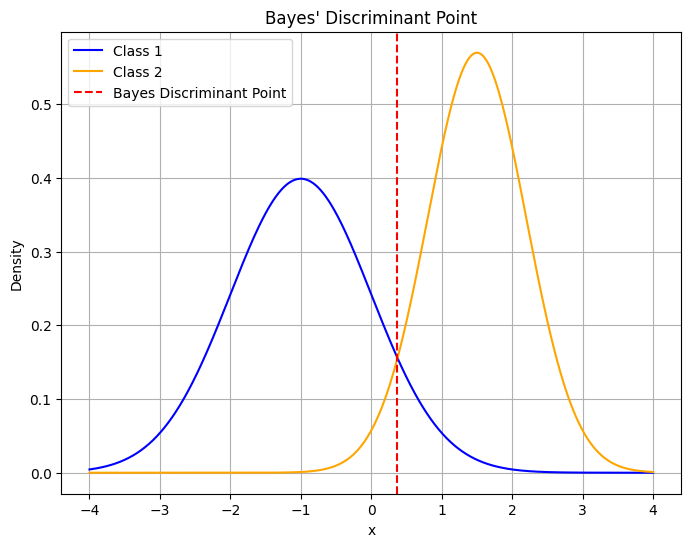

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 定義兩個正態分佈的參數
mu1, sigma1 = -1, 1  # Class 1
mu2, sigma2 = 1.5, 0.7  # Class 2

# 生成 x 值範圍
x = np.linspace(-4, 4, 1000)

# 計算兩個類別的概率密度函數
p_x_given_C1 = norm.pdf(x, mu1, sigma1)
p_x_given_C2 = norm.pdf(x, mu2, sigma2)

# 計算貝氏判別點 (通過兩個正態分佈的交點)
a = 1 / (2 * sigma1**2) - 1 / (2 * sigma2**2)
b = mu2 / sigma2**2 - mu1 / sigma1**2
c = mu1**2 / (2 * sigma1**2) - mu2**2 / (2 * sigma2**2) - np.log(sigma2 / sigma1)

discriminant_points = np.roots([a, b, c])

# 選擇位於兩個均值之間的解作為唯一的貝氏判別點
discriminant_point = discriminant_points[(discriminant_points > mu1) & (discriminant_points < mu2)].real[0]

# 繪圖
plt.figure(figsize=(8, 6))
plt.plot(x, p_x_given_C1, label="Class 1", color="blue")
plt.plot(x, p_x_given_C2, label="Class 2", color="orange")

# 繪製唯一的貝氏判別點
plt.axvline(x=discriminant_point, color="red", linestyle="--", label="Bayes Discriminant Point")

# 標注圖形
plt.title("Bayes' Discriminant Point")
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()

# 顯示圖形
plt.grid(True)
plt.show()
